<!-- codex-purpose-v2 -->
# 02 - EfficientNet-B0 Disease Classifier

## Purpose
Train the image-level classifier used by the whole weakly supervised
segmentation pipeline.

## Research Thinking
- The classifier provides both disease prediction and feature maps for
  GradCAM/GradCAM++.
- EfficientNet-B0 is compact enough for thesis-scale experiments and practical
  deployment.
- Strong classification accuracy supports heatmap generation, but it does not
  prove pixel-level segmentation correctness.

## Inputs / Outputs
- Input: raw train/val/test images.
- Output: classifier checkpoint, training history, test metrics, confusion
  matrix, and per-class performance.

## How To Read The Result
Read this as the prerequisite model for XAI. Segmentation quality must still be
validated separately, especially on GT_OK/manual masks.


# 02 · Classification Baseline — EfficientNet-B0

Huấn luyện mô hình phân loại bệnh lá sầu riêng bằng EfficientNet-B0 với transfer learning từ ImageNet. Đây là bước đầu trong pipeline: phân loại trước, phân vùng sau.

---

**Bài toán hiện tại**

- **Target:** nhãn bệnh ở mức ảnh, lấy từ thư mục lớp.
- **Feature:** tensor ảnh RGB 224×224 sau augmentation/normalization; không có feature tabular thủ công đưa vào mô hình.
- **Kiểu bài toán:** **multiclass classification 5 lớp**, single-label, không phải binary classification.
- **Lớp:** Algal Leaf Spot, Allocaridara Attack, Healthy Leaf, Leaf Blight, Phomopsis Leaf Spot.

**Những gì notebook này làm:**

1. **Load dữ liệu** — sử dụng split 70/10/20 đã chuẩn bị từ notebook 01
2. **Audit dữ liệu cho classification** — missing/unreadable file, duplicate, leakage theo split, imbalance, outlier ảnh
3. **Khởi tạo mô hình** — EfficientNet-B0 pretrained, fine-tune toàn bộ
4. **Training loop** — early stopping (max 50 epochs), Adam lr=1e-4, ReduceLROnPlateau
5. **Visualize training** — loss & accuracy curves theo epoch
6. **Đánh giá test set** — accuracy, precision, recall, F1 per-class, confusion matrix
7. **Bổ sung đánh giá nâng cao** — classification report, ROC-AUC/PR-AUC one-vs-rest, confidence/error analysis, gợi ý calibration/threshold nếu cần triển khai

**Kết quả sau lần chạy mới:** Val accuracy **98.42%** (epoch 16) · Test accuracy **97.19%** · Weighted F1 **97.19%** · Macro ROC-AUC **99.87%** · Macro PR-AUC **99.51%**

**Output:** Model checkpoint tại `models/classification/checkpoints/` · Metrics tại `models/classification/metrics/` · Figures tại `visualizations/classification/`


In [1]:
import os
import sys
import json
proj_root = r'E:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from utils.preprocessing import DataLoader as DurianDataLoader
from utils.models import EfficientNetClassifier
from utils.metrics import ModelEvaluator

# Plot style — nhất quán với notebook 01
plt.style.use('default')
sns.set_palette("husl")

# Okabe-Ito palette — colorblind-safe, nhất quán với notebook 01
CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]

VIZ_DIR = "visualizations/classification"
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Class Label Mapping

| Label | Tên lớp | Thư mục |
|:---:|---|---|
| **0** | Algal Leaf Spot | `ALGAL_LEAF_SPOT/` |
| **1** | Allocaridara Attack | `ALLOCARIDARA_ATTACK/` |
| **2** | Healthy Leaf | `HEALTHY_LEAF/` |
| **3** | Leaf Blight | `LEAF_BLIGHT/` |
| **4** | Phomopsis Leaf Spot | `PHOMOPSIS_LEAF_SPOT/` |

Label được gán theo **thứ tự alphabet** của tên thư mục (do `torchvision.datasets.ImageFolder` sort theo tên). Thứ tự này nhất quán giữa train/val/test và không thay đổi giữa các lần chạy.

**Quan sát chính:** Label được ánh xạ theo thứ tự alphabet của thư mục, từ 0 đến 4, và mỗi ảnh chỉ có một nhãn.

**Đánh giá:** Đây là thiết lập multiclass single-label phù hợp với `nn.CrossEntropyLoss`; không cần sigmoid/multi-label loss.

**Rủi ro hoặc hạn chế:** Nếu sau này thêm/xóa/đổi tên thư mục lớp, mapping có thể thay đổi âm thầm và làm sai checkpoint hoặc confusion matrix cũ.

**Hàm ý cải thiện:** Luôn lưu `CLASS_NAMES`/mapping cùng checkpoint và metrics JSON để inference ở notebook 10 không phụ thuộc vào thứ tự thư mục runtime.


## Load Dữ liệu

EDA xong rồi — đã biết data trông như thế nào, split như thế nào. Bước này chỉ đơn giản là lấy data vào.

Một điểm nhỏ cần chú ý: train loader phải bật `is_training=True` để có augmentation (flip, crop, jitter màu), còn val và test thì không. Nếu augment cả val thì số đo được sẽ bị nhiễu — mỗi lần đánh giá lại ra kết quả khác nhau.

In [2]:
data_loader = DurianDataLoader('data/raw', batch_size=16, image_size=(224,224))
splits = data_loader.load_dataset()
print('Splits count:', {k:len(v) for k,v in splits.items()})
print('Class distribution:', data_loader.get_class_distribution())

train_loader = data_loader.get_data_loader('train', is_training=True)
val_loader = data_loader.get_data_loader('val', is_training=False)
test_loader = data_loader.get_data_loader('test', is_training=False)

Splits count: {'train': 3104, 'val': 443, 'test': 890}
Class distribution: {0: 733, 1: 913, 2: 976, 3: 937, 4: 878}


### Audit dữ liệu, split và leakage

Cell dưới đây gom lại các kiểm tra đã có từ notebook 01/manifest để notebook classification tự nói rõ chất lượng dữ liệu đầu vào: số mẫu theo split/lớp, mức imbalance, missing/unreadable file, duplicate hash, và leakage giữa train/val/test.


In [3]:
from collections import Counter
from pathlib import Path

processed_dir = Path("data/processed")
stats_path = processed_dir / "dataset_statistics.json"
summary_path = processed_dir / "dataset_summary_clean.json"
manifest_path = processed_dir / "image_manifest.csv"

split_class_counts = {
    split: Counter(img.class_label for img in split_images)
    for split, split_images in splits.items()
}

print("Split x class counts")
for split, counts in split_class_counts.items():
    print(split, {CLASS_LABELS[k]: counts.get(k, 0) for k in range(len(CLASS_LABELS))})

total_by_class = Counter()
for counts in split_class_counts.values():
    total_by_class.update(counts)

max_class = max(total_by_class.values())
min_class = min(total_by_class.values())
imbalance_ratio = max_class / min_class
majority_test_baseline = max(split_class_counts["test"].values()) / len(splits["test"])

print(f"\nImbalance ratio max/min: {imbalance_ratio:.2f}x")
print(f"Majority-class baseline trên test: {majority_test_baseline:.2%}")

if stats_path.exists():
    with open(stats_path, "r", encoding="utf-8") as f:
        dataset_stats = json.load(f)

    print("\nIntegrity summary")
    for row in dataset_stats.get("integrity_summary", []):
        print(f"- {row['Metric']}: {row['Value']}")

    print("\nOutlier summary")
    for row in dataset_stats.get("outlier_summary", []):
        print(f"- {row['feature']}: {row['n_outliers']} ảnh ({row['outlier_pct']}%)")
else:
    print(f"Không tìm thấy {stats_path}; hãy chạy notebook 01 để có audit đầy đủ.")


Split x class counts
train {'Algal Leaf Spot': 513, 'Allocaridara Attack': 639, 'Healthy Leaf': 683, 'Leaf Blight': 655, 'Phomopsis Leaf Spot': 614}
val {'Algal Leaf Spot': 73, 'Allocaridara Attack': 91, 'Healthy Leaf': 97, 'Leaf Blight': 94, 'Phomopsis Leaf Spot': 88}
test {'Algal Leaf Spot': 147, 'Allocaridara Attack': 183, 'Healthy Leaf': 196, 'Leaf Blight': 188, 'Phomopsis Leaf Spot': 176}

Imbalance ratio max/min: 1.33x
Majority-class baseline trên test: 22.02%

Integrity summary
- Total manifest rows: 4437
- Missing files: 0
- Unreadable files: 0
- Non-image extensions: 0
- Unique image sizes: 1
- Exact duplicate hash groups: 1
- Images inside duplicate hash groups: 2
- Cross-split exact hash leakage groups: 0
- Cross-split filename overlap groups: 0

Outlier summary
- file_size_kb: 31 ảnh (0.7%)
- brightness: 51 ảnh (1.15%)
- contrast: 48 ảnh (1.08%)
- saturation: 123 ảnh (2.77%)
- green_excess: 59 ảnh (1.33%)


**Quan sát chính:** Output hiện có cho thấy dataset có **4,437 ảnh**, split **train/val/test = 3,104/443/890**. Phân bố lớp toàn bộ là 733, 913, 976, 937, 878 ảnh; theo test là 147, 183, 196, 188, 176 ảnh. Notebook 01 ghi nhận **0 missing file**, **0 unreadable file**, **0 non-image extension**, **1 duplicate hash group gồm 2 ảnh**, và **0 cross-split exact-hash leakage / 0 filename overlap giữa split**. Outlier theo đặc trưng ảnh thấp: file size 0.70%, brightness 1.15%, contrast 1.08%, saturation 2.77%, green_excess 1.33%.

**Đánh giá:** Split đang gần stratified: mỗi lớp giữ tỷ lệ xấp xỉ 70/10/20. Imbalance max/min khoảng **1.33x** nên chưa nghiêm trọng; majority baseline trên test chỉ khoảng **22.02%**, thấp hơn rất xa so với test accuracy **97.19%**. Không có dấu hiệu leakage exact duplicate giữa train/val/test theo audit hiện có.

**Rủi ro hoặc hạn chế:** Vẫn còn 2 ảnh exact duplicate trong cùng dataset; nếu nằm cùng một split thì không làm phồng test trực tiếp, nhưng có thể làm model hơi thiên về pattern lặp. Audit mới kiểm exact hash và filename, chưa bắt near-duplicate như ảnh crop/resize/đổi sáng từ cùng nguồn.

**Hàm ý cải thiện:** Trước khi báo cáo cuối cùng, nên loại hoặc đánh dấu duplicate nội bộ, bổ sung perceptual hash/embedding similarity để bắt near-duplicate, và lưu snapshot split cố định. Với imbalance 1.33x, chưa bắt buộc dùng sampling/class_weight, nhưng nên theo dõi macro F1 và per-class recall thay vì chỉ accuracy.


## Khởi tạo Model

3,100 ảnh train thực ra không nhiều. Train CNN từ đầu với số này thường overfit nhanh — model học thuộc training set thay vì học cách nhận biết bệnh. Nên dùng EfficientNet-B0 pretrained từ ImageNet, tận dụng những feature đã học được (cạnh, texture, màu sắc), rồi fine-tune lại cho bài toán lá bệnh.

Một vài lựa chọn đáng chú ý:
- **Fine-tune toàn bộ** chứ không chỉ linear head — dataset đủ lớn để không lo catastrophic forgetting
- **lr = 1e-4** — nếu học quá nhanh sẽ overwrite ngay pretrained weights, mất đi những gì nó đã học
- **ReduceLROnPlateau** thay vì schedule cứng — tự giảm lr khi model bắt đầu stuck, không cần đoán trước

### Baseline tối thiểu và lựa chọn loss

Trước khi train deep model, cần có baseline cực đơn giản để biết mô hình có học được tín hiệu thật hay chỉ tốt hơn ngẫu nhiên một chút. Với multiclass 5 lớp gần cân bằng, majority-class baseline trên test khoảng 22.02%.


In [4]:
num_classes = len(CLASS_LABELS)
train_counts = np.array([split_class_counts["train"].get(i, 0) for i in range(num_classes)])
test_counts = np.array([split_class_counts["test"].get(i, 0) for i in range(num_classes)])

majority_class_idx = int(np.argmax(train_counts))
majority_baseline_acc = test_counts[majority_class_idx] / test_counts.sum()
random_prior_baseline_acc = np.sum((test_counts / test_counts.sum()) ** 2)

class_weights = train_counts.sum() / (num_classes * train_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

print(f"Majority baseline class: {CLASS_LABELS[majority_class_idx]}")
print(f"Majority baseline accuracy trên test: {majority_baseline_acc:.2%}")
print(f"Random-prior expected accuracy trên test: {random_prior_baseline_acc:.2%}")
print("Class weights gợi ý nếu cần:", dict(zip(CLASS_LABELS, np.round(class_weights, 3))))

# Dataset chỉ lệch ~1.33x nên mặc định giữ loss không weight để so sánh công bằng.
# Nếu sau này ưu tiên recall lớp hiếm hoặc split mới mất cân bằng hơn, bật dòng dưới:
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


Majority baseline class: Healthy Leaf
Majority baseline accuracy trên test: 22.02%
Random-prior expected accuracy trên test: 20.18%
Class weights gợi ý nếu cần: {'Algal Leaf Spot': np.float64(1.21), 'Allocaridara Attack': np.float64(0.972), 'Healthy Leaf': np.float64(0.909), 'Leaf Blight': np.float64(0.948), 'Phomopsis Leaf Spot': np.float64(1.011)}


**Quan sát chính:** Baseline majority trên test khoảng **22.02%**; random theo prior lớp khoảng **20.18%**. Mô hình hiện dùng `CrossEntropyLoss` không weight.

**Đánh giá:** Với 5 lớp gần cân bằng, loss không weight là lựa chọn hợp lý cho baseline chính. Vì test accuracy đạt **97.19%**, mô hình vượt baseline khoảng **75.17 điểm phần trăm**, cho thấy CNN học được tín hiệu ảnh rõ ràng.

**Rủi ro hoặc hạn chế:** Chưa có baseline nhẹ hơn như logistic regression trên embedding, linear probe, hoặc frozen-backbone head-only để tách lợi ích của fine-tuning toàn bộ.

**Hàm ý cải thiện:** Giữ EfficientNet-B0 fine-tune làm model chính; nếu cần ablation cho luận văn, thêm 2 baseline: frozen EfficientNet head-only và ResNet18/MobileNetV3. Class weight chỉ nên bật nếu split mới lệch mạnh hơn hoặc recall lớp quan trọng giảm.


In [5]:
num_classes = len(CLASS_LABELS)
model = EfficientNetClassifier(num_classes=num_classes, backbone='efficientnet_b0', pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
evaluator = ModelEvaluator(device=device)

print(f"Model: EfficientNet-B0 | Classes: {num_classes} | Device: {device}")

Model: EfficientNet-B0 | Classes: 5 | Device: cuda


**Quan sát chính:** Model chính là EfficientNet-B0 pretrained ImageNet, thay classifier head bằng dropout 0.2 + linear 5 lớp; optimizer Adam lr=1e-4; scheduler ReduceLROnPlateau theo val accuracy.

**Đánh giá:** Đây là cấu hình hợp lý cho dataset ảnh nhỏ-vừa. Với ảnh RGB đã resize 224×224 và normalization ImageNet, pretrained EfficientNet-B0 là feature extractor phù hợp hơn so với train CNN từ đầu.

**Rủi ro hoặc hạn chế:** Notebook chưa log seed đầy đủ ở cell training, chưa lưu optimizer/scheduler state, chưa ghi rõ version torchvision/checkpoint mapping. Cross-validation không được dùng; với deep learning ảnh, k-fold sẽ tốn tài nguyên, nhưng một holdout duy nhất vẫn có độ bất định.

**Hàm ý cải thiện:** Lưu thêm `class_names`, `optimizer_state_dict`, `history`, seed, transform config vào checkpoint. Nếu cần độ tin cậy thống kê, chạy repeated stratified holdout hoặc k-fold nhẹ với frozen backbone thay vì full fine-tune tất cả fold.


## Training Loop

Vòng lặp train chính. Mỗi epoch đi qua toàn bộ train set một lần, rồi ngay lập tức check trên val set để biết đang ở đâu.

Thay vì cố định 10 epoch, để **early stopping** tự quyết định khi nào dừng. Logic đơn giản: nếu val_acc không cải thiện sau `patience` epoch liên tiếp thì dừng — lúc đó tiếp tục train thêm chỉ làm model overfit thêm chứ không được gì. Best model đã được lưu rồi nên không mất gì cả.

Một vài chỗ dễ bị bỏ qua:
- `model.train()` / `model.eval()` bật/tắt dropout và batch norm — không phải convention, ảnh hưởng thực sự đến kết quả
- `torch.no_grad()` ở val loop để khỏi tốn memory tính gradient khi không dùng đến
- Checkpoint chỉ ghi đè khi val_acc vượt best — file `best_model.pth` luôn là model tốt nhất tính đến thời điểm hiện tại

**Quan sát chính:** Output training mới: val accuracy tăng từ **85.10%** epoch 1 lên best **98.42%** tại epoch 16; early stopping dừng ở epoch 21. Train accuracy cuối là **98.97%**, val accuracy cuối **98.42%**; best checkpoint đã được load lại từ epoch 16 trước khi test.

**Đánh giá:** Mô hình hội tụ tốt và đạt đỉnh validation muộn hơn lần output cũ. Sau epoch 16, train loss tiếp tục giảm nhưng val accuracy không vượt best trong 5 epoch liên tiếp, nên early stopping dừng hợp lý.

**Rủi ro hoặc hạn chế:** Dù train/val gap cuối nhỏ, val set đã dùng cho checkpoint selection và scheduler nên không còn hoàn toàn khách quan. Test set vẫn là nguồn đánh giá chính.

**Hàm ý cải thiện:** Giữ quy trình load `best_model.pth` trước test và trước Grad-CAM. Nếu muốn báo cáo độ ổn định, nên chạy thêm repeated holdout/seed khác thay vì chỉ dựa vào một lần split + một seed.


In [6]:
max_epochs    = 50
patience      = 5   # dừng nếu không cải thiện sau 5 epoch liên tiếp

best_val_acc      = 0.0
early_stop_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
os.makedirs('models/classification/checkpoints', exist_ok=True)

for epoch in range(1, max_epochs + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{max_epochs} [train]', leave=False):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            _, preds     = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:>3}/{max_epochs} | '
          f'train loss {train_loss:.4f}  acc {train_acc:.4f} | '
          f'val loss {val_loss:.4f}  acc {val_acc:.4f}', end='')

    scheduler.step(val_acc)

    # ── Checkpoint & Early Stopping ────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc       = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_acc':          val_acc,
        }, 'models/classification/checkpoints/best_model.pth')
        print(f'  ✓ best ({val_acc:.4f}) saved')
    else:
        early_stop_counter += 1
        print(f'  no improve {early_stop_counter}/{patience}')
        if early_stop_counter >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

print(f'\nDone. Best val accuracy: {best_val_acc * 100:.2f}%')

Epoch 1/50 [train]:   0%|          | 0/194 [00:00<?, ?it/s]

Epoch   1/50 | train loss 1.1002  acc 0.5870 | val loss 0.4715  acc 0.8510  ✓ best (0.8510) saved


Epoch   2/50 | train loss 0.4196  acc 0.8553 | val loss 0.1944  acc 0.9458  ✓ best (0.9458) saved


Epoch   3/50 | train loss 0.3075  acc 0.8959 | val loss 0.1724  acc 0.9436  no improve 1/5


Epoch   4/50 | train loss 0.2378  acc 0.9191 | val loss 0.1333  acc 0.9549  ✓ best (0.9549) saved


...

Epoch  17/50 | train loss 0.0528  acc 0.9823 | val loss 0.0592  acc 0.9752  no improve 1/5


Epoch  18/50 | train loss 0.0475  acc 0.9865 | val loss 0.0480  acc 0.9774  no improve 2/5


Epoch  19/50 | train loss 0.0432  acc 0.9861 | val loss 0.0798  acc 0.9707  no improve 3/5


Epoch  20/50 | train loss 0.0366  acc 0.9871 | val loss 0.0602  acc 0.9729  no improve 4/5


Epoch  21/50 | train loss 0.0359  acc 0.9897 | val loss 0.0419  acc 0.9842  no improve 5/5

Early stopping triggered at epoch 21.

Done. Best val accuracy: 98.42%


## Lưu Training History

Training chạy cả tiếng. Nếu kernel reset mà không lưu gì thì mất hết. Lưu `history` ra JSON để sau này muốn plot lại, so sánh với experiment khác, hay viết vào paper — không cần phải retrain lại từ đầu.

In [7]:
import json
history_path = 'models/classification/metrics/training_history.json'
os.makedirs(os.path.dirname(history_path), exist_ok=True)
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print('Saved history to', history_path)

Saved history to models/classification/metrics/training_history.json


### Visualize Training Curves

Nhìn log text không tiện. Plot ra thì thấy ngay ba thứ quan trọng:
- Loss có đang giảm đều không, hay bị dao động mạnh
- Val loss có bắt đầu đi lên trong khi train loss vẫn xuống không — đó là overfit
- Hai đường train và val có converge gần nhau không — nếu gap quá lớn thì cần regularization thêm

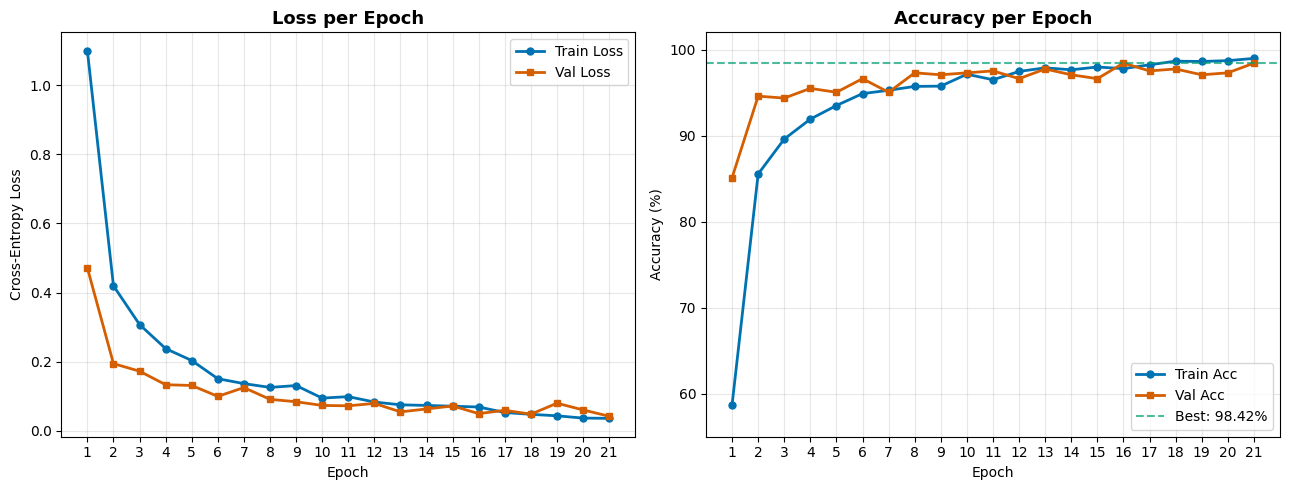

Saved → visualizations/classification/training_curves.png
Best Val Accuracy: 98.42% at epoch 16


In [8]:
train_loss = history['train_loss']
val_loss   = history['val_loss']
train_acc  = history['train_acc']
val_acc    = history['val_acc']
epoch_range = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epoch_range, train_loss, "o-", color="#0072B2", linewidth=2, markersize=5, label="Train Loss")
ax1.plot(epoch_range, val_loss,   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val Loss")
ax1.set_title("Loss per Epoch", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.set_xticks(list(epoch_range))
ax1.grid(True, alpha=0.3)

ax2.plot(epoch_range, [a * 100 for a in train_acc], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train Acc")
ax2.plot(epoch_range, [a * 100 for a in val_acc],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val Acc")
best_acc = max(val_acc) * 100
ax2.axhline(y=best_acc, color="#009E73", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Best: {best_acc:.2f}%")
ax2.set_title("Accuracy per Epoch", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.set_xticks(list(epoch_range))
ax2.set_ylim(55, 102)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/training_curves.png")
print(f"Best Val Accuracy: {best_acc:.2f}% at epoch {val_acc.index(max(val_acc)) + 1}")

## Đánh giá trên Test Set

Val set không còn khách quan nữa — đã dùng nó để chọn checkpoint tốt nhất và để scheduler điều chỉnh lr. Nói cách khác, model đã được optimize theo val set một cách gián tiếp rồi.

Test set mới là con số thật. Đây là lần đầu tiên model gặp những ảnh này — và cũng là lần cuối. Chạy xong thì báo cáo số đó, không được quay lại tune thêm rồi chạy lại.

### Load best checkpoint trước khi test

Cell này sửa một rủi ro nhỏ nhưng quan trọng của notebook gốc: sau early stopping, object `model` vẫn ở epoch cuối đã chạy, không tự quay về epoch tốt nhất. Vì checkpoint tốt nhất đã được lưu, test nên dùng checkpoint đó. Trong lần chạy mới, checkpoint tốt nhất là epoch 16.


In [9]:
best_ckpt_path = "models/classification/checkpoints/best_model.pth"

if os.path.exists(best_ckpt_path):
    checkpoint = torch.load(best_ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    print(f"Loaded best checkpoint from epoch {checkpoint.get('epoch')} with val_acc={checkpoint.get('val_acc', float('nan')):.4f}")
else:
    print(f"Không tìm thấy {best_ckpt_path}; đang evaluate model hiện tại trong memory.")


Loaded best checkpoint from epoch 16 with val_acc=0.9842


In [14]:
test_metrics = evaluator.evaluate_classification(model, test_loader)
print(test_metrics)
metrics_path = 'models/classification/metrics/test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)
print('Saved test metrics to', metrics_path)

# ModelEvaluator có thể gọi model.to(...); ép lại device notebook để các cell sau không mismatch CPU/CUDA.
model.to(device)
model.eval()
print(f'Model device after evaluation: {next(model.parameters()).device}')

{'accuracy': 0.9719101123595506, 'precision': 0.972232436668062, 'recall': 0.9719101123595506, 'f1_score': 0.9719124158244193, 'precision_per_class': [0.9466666666666667, 0.9574468085106383, 0.9798994974874372, 1.0, 0.9707602339181286], 'recall_per_class': [0.9659863945578231, 0.9836065573770492, 0.9948979591836735, 0.9680851063829787, 0.9431818181818182], 'f1_per_class': [0.9562289562289562, 0.9703504043126685, 0.9873417721518988, 0.9837837837837838, 0.9567723342939481], 'confusion_matrix': [[142, 1, 1, 0, 3], [2, 180, 0, 0, 1], [1, 0, 195, 0, 0], [1, 3, 1, 182, 1], [4, 4, 2, 0, 166]], 'num_samples': 890, 'num_classes': 5}
Saved test metrics to models/classification/metrics/test_metrics.json
Model device after evaluation: cuda:0


**Quan sát chính:** Output test mới ghi **865/890 ảnh đúng**, accuracy **97.19%**, weighted precision **97.22%**, weighted recall **97.19%**, weighted F1 **97.19%**. Macro precision/recall/F1 lần lượt là **97.10% / 97.12% / 97.09%**.

**Đánh giá:** Vì bài toán 5 lớp gần cân bằng, accuracy vẫn có ý nghĩa, nhưng metric chính nên là **macro/weighted F1 + per-class recall**. Macro F1 gần weighted F1 cho thấy không có lớp nhỏ bị che lấp bởi lớp lớn.

**Rủi ro hoặc hạn chế:** Test accuracy thấp hơn val best khoảng **1.23 điểm phần trăm**; gap này nhỏ và chấp nhận được, nhưng vẫn cần đọc lỗi cụ thể vì một số lỗi có confidence cao.

**Hàm ý cải thiện:** Giữ classification report, ROC-AUC/PR-AUC one-vs-rest và confidence/error table trong báo cáo. Với multiclass, threshold tuning kiểu binary không áp dụng trực tiếp; nếu triển khai cần cơ chế abstain/top-2 review dựa trên confidence.


### Classification report, ROC-AUC/PR-AUC và confidence

Đây là phần đánh giá bổ sung cho multiclass classification. ROC/PR được tính theo one-vs-rest từng lớp vì bài toán không phải binary. PR-AUC đặc biệt hữu ích nếu split tương lai mất cân bằng hơn.


In [15]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

all_y_true, all_y_pred, all_y_prob, all_filenames = [], [], [], []

eval_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(eval_device)
model.eval()
print(f"Evaluation device: {eval_device}; model device: {next(model.parameters()).device}")

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(eval_device)
        labels = batch["label"].to(eval_device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_y_true.extend(labels.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())
        all_y_prob.extend(probs.cpu().numpy())
        all_filenames.extend(batch["filename"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

report = classification_report(
    all_y_true,
    all_y_pred,
    target_names=CLASS_LABELS,
    digits=4,
    zero_division=0,
)
print(report)

y_true_ovr = label_binarize(all_y_true, classes=np.arange(num_classes))
roc_auc_macro = roc_auc_score(y_true_ovr, all_y_prob, average="macro", multi_class="ovr")
pr_auc_macro = average_precision_score(y_true_ovr, all_y_prob, average="macro")
roc_auc_per_class = roc_auc_score(y_true_ovr, all_y_prob, average=None, multi_class="ovr")
pr_auc_per_class = average_precision_score(y_true_ovr, all_y_prob, average=None)

print(f"Macro ROC-AUC OVR: {roc_auc_macro:.4f}")
print(f"Macro PR-AUC OVR : {pr_auc_macro:.4f}")
for name, roc_auc, pr_auc in zip(CLASS_LABELS, roc_auc_per_class, pr_auc_per_class):
    print(f"{name:22s} ROC-AUC={roc_auc:.4f} | PR-AUC={pr_auc:.4f}")

confidence = all_y_prob.max(axis=1)
error_mask = all_y_true != all_y_pred
print(f"Mean confidence đúng: {confidence[~error_mask].mean():.4f}")
print(f"Mean confidence sai : {confidence[error_mask].mean():.4f}" if error_mask.any() else "Không có lỗi trên test.")

enhanced_metrics = {
    "classification_report": report,
    "roc_auc_macro_ovr": float(roc_auc_macro),
    "pr_auc_macro_ovr": float(pr_auc_macro),
    "roc_auc_per_class_ovr": dict(zip(CLASS_LABELS, [float(x) for x in roc_auc_per_class])),
    "pr_auc_per_class_ovr": dict(zip(CLASS_LABELS, [float(x) for x in pr_auc_per_class])),
    "mean_confidence_correct": float(confidence[~error_mask].mean()),
    "mean_confidence_incorrect": float(confidence[error_mask].mean()) if error_mask.any() else None,
}

enhanced_metrics_path = "models/classification/metrics/test_metrics_enhanced.json"
with open(enhanced_metrics_path, "w", encoding="utf-8") as f:
    json.dump(enhanced_metrics, f, indent=2, ensure_ascii=False)
print("Saved enhanced metrics to", enhanced_metrics_path)


Evaluation device: cuda; model device: cuda:0
                     precision    recall  f1-score   support

    Algal Leaf Spot     0.9467    0.9660    0.9562       147
Allocaridara Attack     0.9574    0.9836    0.9704       183
       Healthy Leaf     0.9799    0.9949    0.9873       196
        Leaf Blight     1.0000    0.9681    0.9838       188
Phomopsis Leaf Spot     0.9708    0.9432    0.9568       176

           accuracy                         0.9719       890
          macro avg     0.9710    0.9712    0.9709       890
       weighted avg     0.9722    0.9719    0.9719       890

Macro ROC-AUC OVR: 0.9987
Macro PR-AUC OVR : 0.9951
Algal Leaf Spot        ROC-AUC=0.9981 | PR-AUC=0.9912
Allocaridara Attack    ROC-AUC=0.9985 | PR-AUC=0.9957
Healthy Leaf           ROC-AUC=0.9995 | PR-AUC=0.9984
Leaf Blight            ROC-AUC=0.9997 | PR-AUC=0.9989
Phomopsis Leaf Spot    ROC-AUC=0.9977 | PR-AUC=0.9912
Mean confidence đúng: 0.9803
Mean confidence sai : 0.7536
Saved enhanced metrics

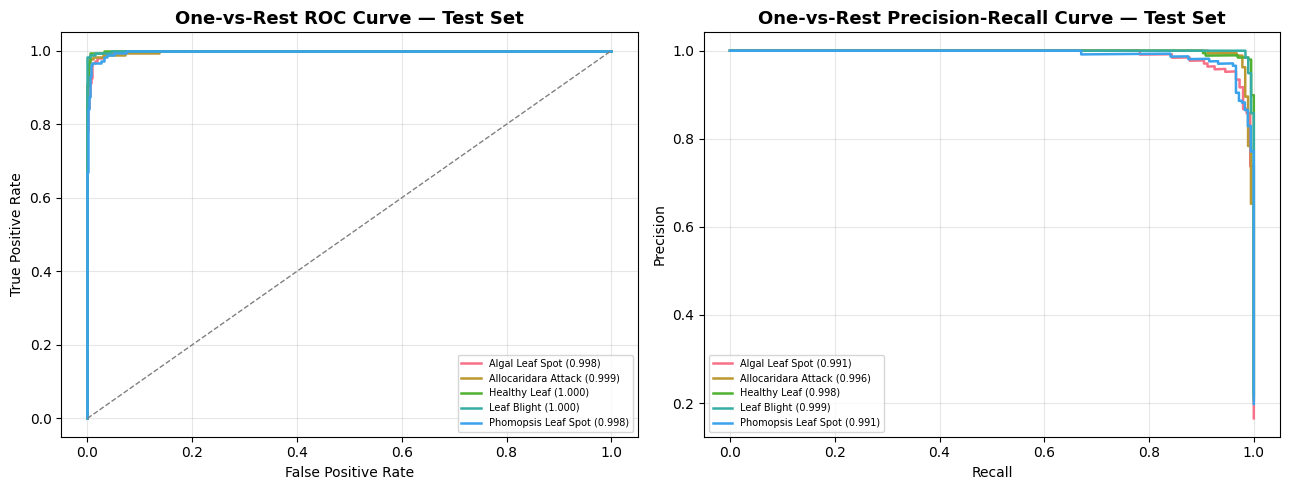

Saved → visualizations/classification/roc_pr_curves_ovr.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, label in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_true_ovr[:, i], all_y_prob[:, i])
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_ovr[:, i], all_y_prob[:, i])

    axes[0].plot(fpr, tpr, linewidth=1.8, label=f"{label} ({roc_auc_per_class[i]:.3f})")
    axes[1].plot(recall_curve, precision_curve, linewidth=1.8, label=f"{label} ({pr_auc_per_class[i]:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("One-vs-Rest ROC Curve — Test Set", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=7)

axes[1].set_title("One-vs-Rest Precision-Recall Curve — Test Set", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "roc_pr_curves_ovr.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/roc_pr_curves_ovr.png")


**Quan sát chính:** ROC/PR mới đã chạy thành công. Macro ROC-AUC OVR đạt **0.9987**, macro PR-AUC OVR đạt **0.9951**. Theo lớp: Algal ROC/PR **0.9981/0.9912**, Allocaridara **0.9985/0.9957**, Healthy **0.9995/0.9984**, Leaf Blight **0.9997/0.9989**, Phomopsis **0.9977/0.9912**.

**Đánh giá:** Các đường ROC/PR cho thấy mô hình xếp hạng đúng lớp rất tốt; ngay cả lớp yếu nhất theo PR-AUC là Algal/Phomopsis vẫn đạt **0.9912**. Điều này nghĩa là xác suất one-vs-rest phân tách lớp tốt, dù argmax cuối cùng vẫn sai 25 ảnh.

**Rủi ro hoặc hạn chế:** ROC-AUC rất cao có thể tạo cảm giác quá an toàn vì bài toán one-vs-rest có nhiều mẫu âm. PR-AUC hữu ích hơn khi đọc từng bệnh, nhưng softmax score vẫn chưa phải xác suất calibrated.

**Hàm ý cải thiện:** Nếu xác suất được dùng để tự động quyết định ngoài thực địa, thêm temperature scaling/calibration curve/ECE trên validation. Nếu có human-in-the-loop, dùng confidence hoặc margin top-1/top-2 để đưa ảnh khó sang review.


**Test set — số thật:**

- **Accuracy 97.19%** trên 890 ảnh chưa từng thấy trong training
- **Macro F1 97.09%** và **weighted F1 97.19%** — hai số gần nhau, cho thấy metric tổng không bị chi phối bởi lớp đông
- **ROC-AUC macro 99.87% / PR-AUC macro 99.51%** — khả năng xếp hạng one-vs-rest rất mạnh
- **Leaf Blight precision 100%** — mỗi lần báo Leaf Blight đều đúng, 0 false positive
- **Healthy Leaf mạnh nhất theo F1**: F1 **98.73%**, recall **99.49%**
- **Phomopsis Leaf Spot yếu nhất theo recall**: recall **94.32%**, F1 **95.68%**; đây là lớp cần soi lỗi nhiều nhất

Gap giữa val best (**98.42%**) và test (**97.19%**) khoảng **1.23 điểm phần trăm** — generalization vẫn tốt, nhưng chưa nên bỏ qua error analysis vì có một số lỗi sai với confidence rất cao.


### Confusion Matrix

Accuracy 97.3% trông ổn, nhưng chưa biết sai ở đâu. Confusion matrix cho thấy điều đó — mỗi ô [i, j] là số ảnh của lớp i bị predict thành lớp j.

Cái đáng xem nhất là những ô ngoài đường chéo, đặc biệt cặp **Algal Leaf Spot ↔ Phomopsis Leaf Spot** — hai lớp này hình thái nhìn khá giống nhau, từ EDA đã thấy dấu hiệu rồi.

**Quan sát chính:** Confusion matrix output mới có tổng **25 lỗi** trên 890 ảnh. Lỗi theo true class: Algal 5/147, Allocaridara 3/183, Healthy 1/196, Leaf Blight 6/188, Phomopsis 10/176.

**Đánh giá:** Lỗi tập trung nhiều nhất ở **Phomopsis Leaf Spot** với 10 ảnh sai, làm recall lớp này thấp nhất (**94.32%**). Leaf Blight vẫn có precision **100%** vì không lớp nào bị dự đoán nhầm thành Leaf Blight, nhưng recall là **96.81%** do 6 ảnh Leaf Blight bị đẩy sang lớp khác.

**Rủi ro hoặc hạn chế:** Phomopsis bị nhầm sang Algal 4 ảnh, Allocaridara 4 ảnh và Healthy 2 ảnh; đây là tín hiệu triệu chứng/texture của Phomopsis có thể chồng lấp với nhiều lớp, không chỉ Algal.

**Hàm ý cải thiện:** Nên xem trực quan các ảnh Phomopsis sai và các lỗi confidence cao. Nếu lỗi là do nhãn mơ hồ, ưu tiên làm sạch nhãn; nếu lỗi do vùng bệnh nhỏ/crop thiếu thông tin, cân nhắc augmentation/crop strategy hoặc attention-guided review bằng Grad-CAM.


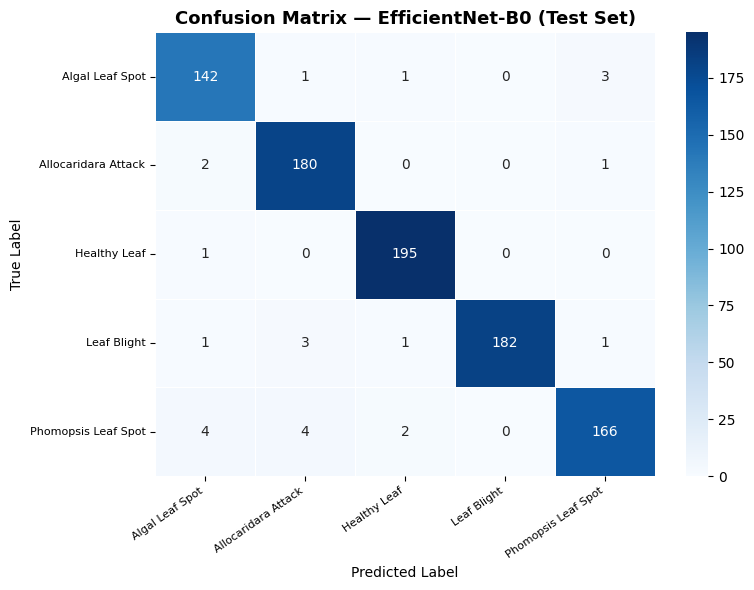

Saved → visualizations/classification/confusion_matrix.png
Overall Accuracy: 865/890 = 97.2%


In [18]:
cm = np.array(test_metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            linewidths=0.5, linecolor="white")
ax.set_title("Confusion Matrix — EfficientNet-B0 (Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(CLASS_LABELS, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_LABELS, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/confusion_matrix.png")
print(f"Overall Accuracy: {cm.diagonal().sum()}/{cm.sum()} = {cm.diagonal().sum()/cm.sum()*100:.1f}%")

**Confusion matrix — nhầm ở đâu:**

Đường chéo gần như sạch: **865/890 ảnh đúng**. Các lỗi đáng chú ý từ output mới:

- **Phomopsis Leaf Spot là lớp khó nhất theo recall:** 10/176 ảnh sai; nhầm sang Algal 4 ảnh, Allocaridara 4 ảnh, Healthy 2 ảnh.
- **Algal Leaf Spot:** 5/147 ảnh sai; nhầm sang Phomopsis 3 ảnh, Allocaridara 1 ảnh, Healthy 1 ảnh.
- **Leaf Blight:** 6/188 ảnh sai; nhầm sang Algal 1, Allocaridara 3, Healthy 1, Phomopsis 1. Không có ảnh lớp khác bị predict thành Leaf Blight, nên precision lớp này vẫn **100%**.
- **Healthy Leaf:** chỉ sai 1/196 ảnh, nhưng lỗi đó là Healthy → Algal; cần kiểm xem có triệu chứng nhẹ hoặc nhãn mơ hồ không.

Tổng cộng model sai **25/890 ảnh**. Với dataset 5 lớp và 3,104 ảnh train, đây là kết quả mạnh; phần cần cải thiện không phải accuracy tổng mà là hiểu bản chất các lỗi Phomopsis và các lỗi confidence cao.


### Per-Class Precision / Recall / F1

Confusion matrix cho thấy số lượng nhầm. Còn chart này cho thấy tỉ lệ — lớp nào đang yếu thực sự.

Với bài toán phát hiện bệnh cây, **recall quan trọng hơn precision**: bỏ sót một ca bệnh thật (false negative) tệ hơn nhiều so với cảnh báo nhầm (false positive). Nên nếu recall của một lớp nào đó thấp thì đó là vấn đề cần để ý, không phải chỉ nhìn accuracy tổng.

**Quan sát chính:** Per-class F1 lần lượt là Algal **95.62%**, Allocaridara **97.04%**, Healthy **98.73%**, Leaf Blight **98.38%**, Phomopsis **95.68%**.

**Đánh giá:** Cả 5 lớp đều vượt F1 95%, không có lớp bị bỏ rơi. Macro F1 **97.09%** gần weighted F1 **97.19%**, nên metric tổng phản ánh khá trung thực hiệu năng giữa các lớp.

**Rủi ro hoặc hạn chế:** Phomopsis có recall thấp nhất (**94.32%**), còn Algal có precision thấp nhất (**94.67%**). Nếu mục tiêu nghiệp vụ là không bỏ sót bệnh, recall của Phomopsis cần được ưu tiên hơn việc tăng thêm accuracy tổng.

**Hàm ý cải thiện:** Thêm review ảnh sai theo confidence, kiểm nhãn các ca Phomopsis/Algal/Leaf Blight, và cân nhắc top-2 prediction hoặc ngưỡng confidence cho ảnh khó.


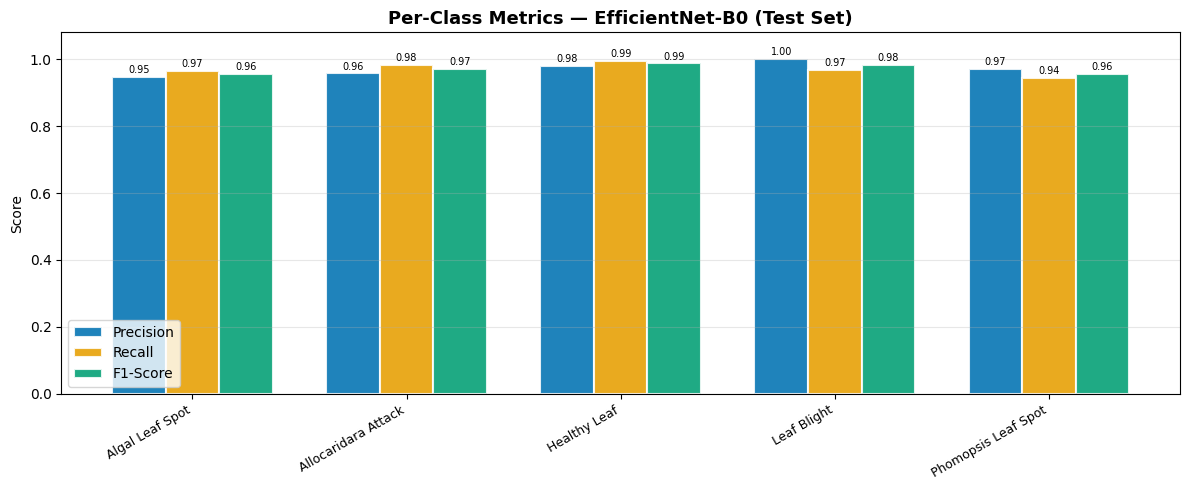

Saved → visualizations/classification/per_class_metrics.png


In [19]:
precision_per_class = test_metrics['precision_per_class']
recall_per_class    = test_metrics['recall_per_class']
f1_per_class        = test_metrics['f1_per_class']

x = np.arange(len(CLASS_LABELS))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, precision_per_class, w, label="Precision", color="#0072B2", alpha=0.88, edgecolor="white", linewidth=1.5)
ax.bar(x,     recall_per_class,    w, label="Recall",    color="#E69F00", alpha=0.88, edgecolor="white", linewidth=1.5)
ax.bar(x + w, f1_per_class,        w, label="F1-Score",  color="#009E73", alpha=0.88, edgecolor="white", linewidth=1.5)

for i, (p, r, f) in enumerate(zip(precision_per_class, recall_per_class, f1_per_class)):
    ax.text(i - w, p + 0.005, f"{p:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i,     r + 0.005, f"{r:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i + w, f + 0.005, f"{f:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_title("Per-Class Metrics — EfficientNet-B0 (Test Set)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "per_class_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/per_class_metrics.png")

### Error analysis: xem các ảnh sai

Metric cho biết sai bao nhiêu; bảng lỗi cho biết sai ở ảnh nào và model tự tin đến mức nào. Đây là phần nên dùng để quyết định cần làm sạch nhãn, thêm dữ liệu, hay đổi augmentation.


In [20]:
error_rows = []
if "all_y_true" in globals() and "all_y_pred" in globals() and "all_y_prob" in globals():
    for filename, true_idx, pred_idx, probs in zip(all_filenames, all_y_true, all_y_pred, all_y_prob):
        if true_idx != pred_idx:
            error_rows.append({
                "filename": filename,
                "true_label": CLASS_LABELS[int(true_idx)],
                "pred_label": CLASS_LABELS[int(pred_idx)],
                "confidence": float(np.max(probs)),
                "true_class_prob": float(probs[int(true_idx)]),
            })

    error_rows = sorted(error_rows, key=lambda x: x["confidence"], reverse=True)
    print(f"Số lỗi: {len(error_rows)}")
    for row in error_rows[:15]:
        print(row)
else:
    print("Hãy chạy cell Classification report/ROC-AUC phía trên trước để tạo all_y_true/all_y_pred/all_y_prob.")


Số lỗi: 25
{'filename': 'to_label_906.jpg', 'true_label': 'Allocaridara Attack', 'pred_label': 'Phomopsis Leaf Spot', 'confidence': 0.9945108890533447, 'true_class_prob': 0.0021375473588705063}
{'filename': 'to_label_4285.jpg', 'true_label': 'Phomopsis Leaf Spot', 'pred_label': 'Allocaridara Attack', 'confidence': 0.9889055490493774, 'true_class_prob': 0.010995559394359589}
{'filename': 'to_label_1276.jpg', 'true_label': 'Allocaridara Attack', 'pred_label': 'Algal Leaf Spot', 'confidence': 0.9863124489784241, 'true_class_prob': 0.011255407705903053}
{'filename': 'to_label_3037.jpg', 'true_label': 'Leaf Blight', 'pred_label': 'Healthy Leaf', 'confidence': 0.9810066819190979, 'true_class_prob': 0.01706629991531372}
{'filename': 'to_label_3827.jpg', 'true_label': 'Phomopsis Leaf Spot', 'pred_label': 'Healthy Leaf', 'confidence': 0.9773279428482056, 'true_class_prob': 0.02093779295682907}
{'filename': 'to_label_2677.jpg', 'true_label': 'Healthy Leaf', 'pred_label': 'Algal Leaf Spot', 'conf

**Quan sát chính:** Error analysis mới liệt kê **25 lỗi**. Mean confidence của dự đoán đúng là **0.9803**, còn dự đoán sai là **0.7536**. Một số lỗi sai có confidence rất cao: `to_label_906.jpg` Allocaridara → Phomopsis confidence **0.9945**, `to_label_4285.jpg` Phomopsis → Allocaridara **0.9889**, `to_label_1276.jpg` Allocaridara → Algal **0.9863**, `to_label_3037.jpg` Leaf Blight → Healthy **0.9810**.

**Đánh giá:** Mô hình nhìn chung tự tin hơn khi đúng, nhưng nhóm lỗi confidence cao cho thấy có những ảnh mà model sai một cách rất chắc. Đây thường là nơi đáng kiểm nhãn/ảnh nhất, vì tuning hyperparameter không chắc giải quyết được.

**Rủi ro hoặc hạn chế:** Nếu lỗi confidence cao là do nhãn sai, triệu chứng chồng lấp hoặc ảnh crop thiếu vùng bệnh, việc tăng epoch/backbone lớn hơn có thể làm overfit lỗi thay vì cải thiện robustness.

**Hàm ý cải thiện:** Review thủ công toàn bộ 25 ảnh sai, bắt đầu từ các lỗi confidence cao. Nên mở ảnh gốc song song với Grad-CAM để phân biệt lỗi do nhãn, do vùng attention sai, hay do đặc trưng bệnh thực sự giống nhau.


**Per-class metrics — pattern đáng chú ý:**

- Cả 5 lớp đều vượt F1 95% — không có lớp nào bị bỏ rơi
- **Healthy Leaf** mạnh nhất: precision **97.99%**, recall **99.49%**, F1 **98.73%**; model tách lá khỏe khỏi lá bệnh khá tốt
- **Leaf Blight** precision **100%** nhưng recall **96.81%**; model rất thận trọng khi gọi Leaf Blight, nhưng vẫn bỏ sót 6 ảnh thật
- **Phomopsis Leaf Spot** là điểm yếu chính theo recall: **94.32%**, với 10 ảnh bị nhầm sang nhiều lớp khác
- **Algal Leaf Spot** có precision thấp nhất: **94.67%**, nghĩa là khi model báo Algal vẫn còn một lượng false positive tương đối cao so với các lớp khác

Kết quả đủ mạnh để dùng cho bước tiếp theo: Grad-CAM sẽ khai thác attention của model để tạo pseudo-label cho segmentation. Tuy nhiên khi phân tích Grad-CAM, nên ưu tiên cả ảnh đúng lẫn các lỗi Phomopsis/Algal confidence cao.


---

## Kết luận rà soát

**Quan sát chính:** Notebook hiện tại giải bài toán **multiclass classification 5 lớp** ở mức ảnh. Dữ liệu có **4,437 ảnh**, split **3,104/443/890**, không có missing/unreadable file và không có exact-hash/filename leakage giữa split theo audit hiện có. EfficientNet-B0 đạt best val accuracy **98.42%** ở epoch 16; output test mới đạt **97.19% accuracy**, **97.19% weighted F1**, **97.09% macro F1**, **865/890 ảnh đúng**. ROC-AUC macro OVR đạt **0.9987** và PR-AUC macro OVR đạt **0.9951**.

**Đánh giá:** Pipeline tổng thể hợp lý cho ảnh: split train/val/test cố định, augmentation chỉ ở train, normalization ImageNet, pretrained EfficientNet-B0, early stopping, load best checkpoint trước test. Accuracy phù hợp vì lớp gần cân bằng, nhưng báo cáo chính nên dùng thêm macro F1, weighted F1, per-class recall, ROC/PR one-vs-rest và confusion matrix. So với majority baseline **22.02%**, model chính vượt rất xa và đủ mạnh để làm classifier nền cho Grad-CAM.

**Rủi ro hoặc hạn chế:** Rủi ro device CPU/CUDA đã được sửa bằng cách cập nhật `ModelEvaluator` và ép `model.to(device)` sau evaluation. Rủi ro còn lại là near-duplicate chưa được audit, softmax probability chưa calibrated, và 25 lỗi test vẫn cần đọc trực quan. Đáng chú ý, một số lỗi sai có confidence rất cao, nên không nên chỉ nhìn accuracy tổng.

**Hàm ý cải thiện:** Notebook đã được bổ sung audit dữ liệu, baseline tối thiểu, ghi chú class weight, bước load best checkpoint, classification report, ROC-AUC/PR-AUC one-vs-rest, confidence/error analysis và nhận xét định lượng dưới từng phần. Trước khi dùng mô hình ngoài thực địa, cần review ảnh sai confidence cao, cân nhắc calibration và đặt cơ chế review cho dự đoán low-confidence hoặc top-1/top-2 quá sát nhau.

**Mô hình/metric tốt nhất hiện tại:** EfficientNet-B0 fine-tune là model tốt nhất trong notebook vì là model duy nhất đã train/evaluate đầy đủ và đạt **97.19% accuracy / 97.19% weighted F1 / 97.09% macro F1** trên test. Với dataset gần cân bằng, weighted F1 và macro F1 gần nhau là tín hiệu tốt; để báo cáo luận văn, nên lấy **macro F1 + per-class recall + confusion matrix + ROC/PR OVR** làm bộ metric chính, accuracy là metric phụ dễ đọc.

**Bước tiếp theo nên làm:**

1. Review toàn bộ **25 ảnh sai**, ưu tiên các lỗi confidence cao như `to_label_906.jpg`, `to_label_4285.jpg`, `to_label_1276.jpg`, `to_label_3037.jpg`.
2. Soi kỹ nhóm **Phomopsis Leaf Spot** vì recall thấp nhất (**94.32%**) và bị nhầm sang nhiều lớp.
3. Thêm calibration curve/ECE nếu xác suất softmax được dùng làm độ tin cậy.
4. Chạy ablation nhẹ: frozen EfficientNet head-only, MobileNetV3/ResNet18, hoặc repeated holdout để ước lượng độ ổn định.
5. Chuyển checkpoint tốt nhất sang notebook 03 và kiểm Grad-CAM trên cả ảnh đúng lẫn ảnh sai trước khi tạo pseudo-label segmentation.
